# Using Nested Sampling instead of MCMC

From the implementation point of view, the main difference between NS and MCMC is in the definition of the priors.

In NS, the prior is defined as the transformation from the unit hypercube to the physical parameter space used by the forward model.

When the physical parameter is explored uniformly (a uniform prior in MCMC), the transformation is simply a rescaling of the boundaries. If the physical parameter is following a Gaussian prior (or any other fucntion), we must define a transformation that converts a uniform distribution between 0 and 1 of the unitary NS parameter, into a Gaussian (or any other function) distribution of the physical parameter. This is accomplished by using the **percent point function***, which is the inverse of the **cumulative distribution function**.

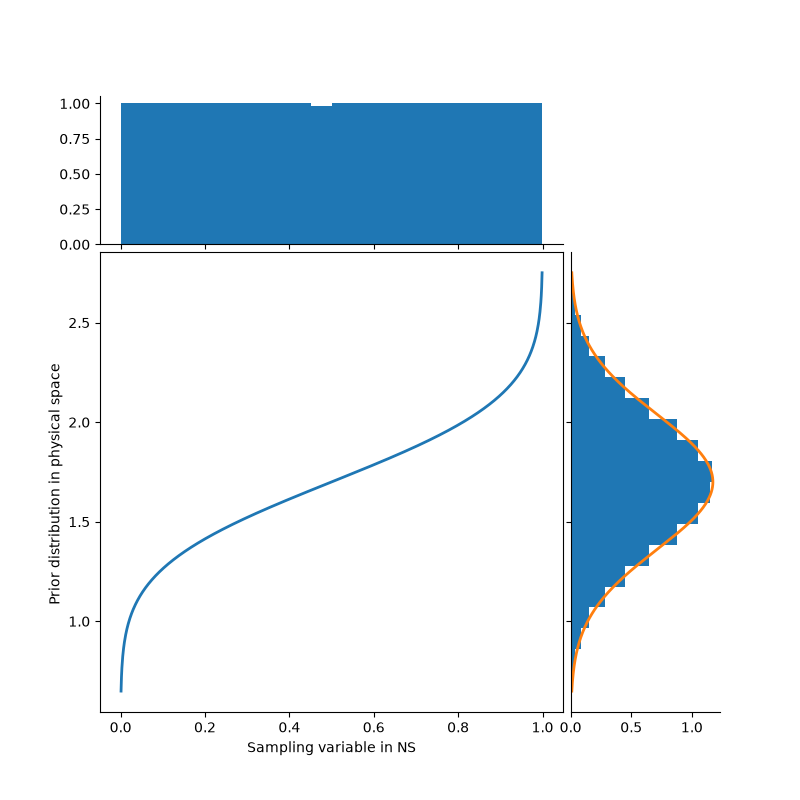

In [2]:
# Percent point function (inverse of cdf) at q of the given RV.
# Inverse of the cumulative distribution function.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import gridspec
%matplotlib widget

# Data
x = np.arange(0, 1, 0.001)
y = stats.norm.ppf(x, loc=1.70, scale=0.34)

# Remove infinities from ppf at x=0 and x=1
mask = np.isfinite(y)
x = x[mask]
y = y[mask]

# Figure layout
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(
    4, 4,
    hspace=0.05,
    wspace=0.05
)

ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

# Scatter plot
ax_scatter.plot(x, y, lw=2)
ax_scatter.set_xlabel("Sampling variable in NS")
ax_scatter.set_ylabel("Prior distribution in physical space ")

# Top histogram (x)
ax_histx.hist(x, bins=20, density=True)
ax_histx.tick_params(axis="x", labelbottom=False)

# Right histogram (y)
ax_histy.hist(y, bins=20, orientation='horizontal', density=True)
ax_histy.tick_params(axis="y", labelleft=False)

yy = np.linspace(y.min(), y.max(), 500)
pdf = stats.norm.pdf(yy, loc=1.70, scale=0.34)

ax_histy.plot(pdf, yy, lw=2)

# Clean up
ax_histx.spines['right'].set_visible(False)
ax_histx.spines['top'].set_visible(False)

ax_histy.spines['right'].set_visible(False)
ax_histy.spines['top'].set_visible(False)

plt.show()

The function to ccomplish this transform looks like this:

In [3]:
def hypercube_transform(u):
    """Transforms samples `u` drawn from the unit cube to model parameters"""

    theta =  boundaries[0,:] + (boundaries[1,:]-boundaries[0,:])*u
    theta[3] = stats.norm.ppf(u[5], 1.70, 0.34)
    theta[5] = stats.norm.ppf(u[5], 0.35, 0.10)
    theta[6] = stats.norm.ppf(u[6], 0.23, 0.10)
    
    return theta

The log_probability function defined in the MCMC case is replaced by the log_lìlikelihood function, as the priors enter through a different channel:

In [ ]:
def log_likelihood(theta):
    return log_likelihood_photometry(theta) + log_likelihood_radial_velocity(theta)

You will still need to define the parameter array and the boundaries, as in the MCMC case. However, with NS you will not need to define the starting point.

Finally, you can check the [dynesty documentation](https://dynesty.readthedocs.io/)  to check how to run the code and how to convert the resulting chains into a format similar to that of MCMC for printing the confidence intervals and building the corner plots

In [4]:
ndim = len(theta)
nlive= 1000

import warnings
warnings.filterwarnings("ignore")

with Pool() as pool:
    pool.size = 6
    dsampler = dynesty.DynamicNestedSampler(log_likelihood, hypercube_transform, ndim, pool=pool, bootstrap=0, nlive=nlive)
    dsampler.run_nested()
dresults = dsampler.results

NameError: name 'theta' is not defined

In [ ]:
res = ("niter: {:d}\n"
        "ncall: {:d}\n"
        "eff(%): {:6.3f}\n"
        "logz: {:6.3f} +/- {:6.3f}"
        .format(dresults.niter, sum(dresults.ncall),
                dresults.eff, dresults.logz[-1], dresults.logzerr[-1]))

print()
print('Summary\n=======\n'+res)

In [ ]:
from dynesty import utils as dyfunc

# Extract sampling results.
samples = dresults.samples  # samples
weights = dresults.importance_weights()

## Compute 10%-90% quantiles.
#quantiles = [dyfunc.quantile(samps, [0.1, 0.9], weights=weights)
#             for samps in samples.T]

## Compute weighted mean and covariance.
#mean, cov = dyfunc.mean_and_cov(samples, weights)

# Resample weighted samples.
samples_equal = dresults.samples_equal()

# Generate a new set of results with sampling uncertainties.
results_sim = dyfunc.resample_run(dresults)

In [ ]:
for i, par_name in enumerate(labels):
    theta_med = compute_value_sigma(samples_equal[:, i])
    s0, s1 = return_significant_figures(theta_med[0], theta_med[2], theta_med[1])
    format_string_long = '{0:12s}  {1:4d}  {2:12.'+repr(max(s0,s1))+'f} {3:12.'+repr(s0)+'f} {4:12.'+repr(s1)+'f}   (15-84 p)   [{5:10.4f}, {6:10.4f}]'
    print(format_string_long.format(
        par_name, i, theta_med[0], theta_med[2], theta_med[1], boundaries[0, i], boundaries[1, i]))


In [ ]:
# List of parameter names, supports latex
# NOTE: For capital greek letters in latex mode, use \mathsf{}

# List of Gaussian curves to plot
#(to represent priors): mean, width
# Empty () or None if no prior to plot
priors = ((),
          (),
          (),
          (1.77, 0.33),
          (),
          (0.50, 0.05),
          (0.10, 0.05),
          (),
         (),
         (),
         (),
         ())

# List of truth values, to mark best-fit or input values
# NOT a python array because of different lengths
# Here we choose two sets of truth values
#truths = ((4, .5, None, .1, 0, None, None, 0),
#          (None, None, .3, 1, None, None, None, None))

# Labels for the different truths
#truthLabels = ( 'the truth',
#               'also true')

# Do the magic
GTC = pygtc.plotGTC(chains=flat_samples,
                    paramNames=labels,
                    #chainLabels=chainLabels,
                    #truths=truths,
                    #truthLabels=truthLabels,
                    priors=priors,
                    figureSize='MNRAS_page',
                    plotName='corner_dynesty_transit_rv_alternative.pdf')